# Tutorial 3: Sweeps and Lag Analysis

In the previous tutorials, we estimated Mutual Information (MI) using a single, fixed set of parameters. But in real-world analysis, we rarely know the perfect parameters in advance.

- **Model Parameters:** What if our neural network isn't deep enough to capture the complexity of the data?
- **Physical Parameters:** What if our time `window_size` is too small to capture the temporal dynamics?
- **Scientific Parameters:** What if there is a transmission delay (lag) between a stimulus $X$ and a neural response $Y$?

In this tutorial, we will use two powerful modes: `mode='sweep'` to search for optimal parameters, and `mode='lag'` to uncover temporal delays between variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import neural_mi as nmi

sns.set_context("talk")

## 1. Generating Data with a Temporal Delay

To make this tutorial realistic, we will generate continuous time-series data. We will create a slow, oscillating signal for $X$. 

For $Y$, we will make it a **delayed** and **noisy** copy of $X$. Specifically, we will delay $Y$ by exactly **0.15 seconds**.

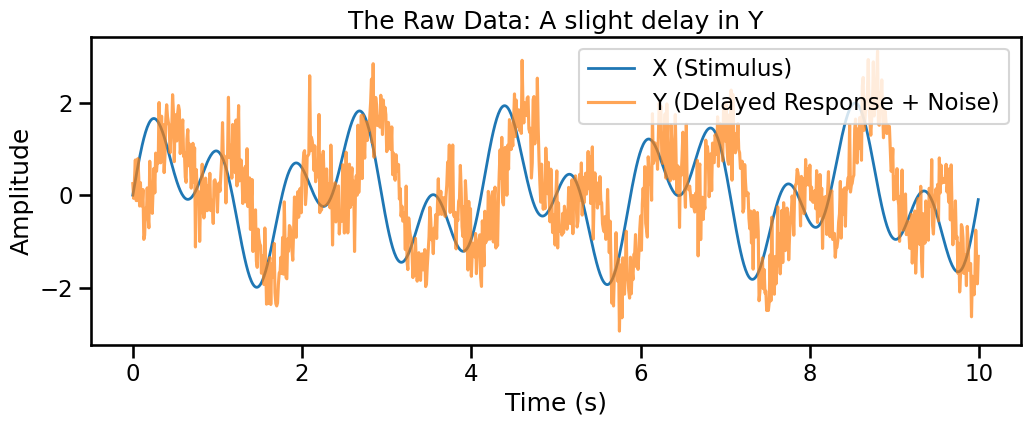

In [33]:
np.random.seed(42)
n_points = 10000
t = np.linspace(0, 100, n_points) # 100 seconds total
dt = t[1] - t[0]                 # 0.01 seconds per step

# Create a smooth signal for X
x_raw = np.sin(2 * np.pi * 0.5 * t) + np.sin(2 * np.pi * 1.2 * t)
x_raw = x_raw.reshape(-1, 1)

# Shift Y by 0.2 seconds (20 steps)
true_lag_steps = 20
y_raw = np.roll(x_raw, shift=true_lag_steps)
y_raw[:true_lag_steps] = 0 # Zero out the wrapped start

# Add noise to Y to make the estimation challenging
y_raw += np.random.randn(*y_raw.shape) * 0.5

plt.figure(figsize=(12, 4))
plt.plot(t[:1000], x_raw[:1000], label='X (Stimulus)', linewidth=2)
plt.plot(t[:1000], y_raw[:1000], label='Y (Delayed Response + Noise)', alpha=0.7)
plt.title("The Raw Data: A slight delay in Y")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
# plt.xlim(0, 2.0)
plt.show()

## 2. Parameter Sweeps (`mode='sweep'`)

Instead of running `nmi.run()` multiple times manually, you can provide a `sweep_grid`. NeuralMI will automatically generate every combination of parameters in the grid and execute them.

Let's sweep over two model parameters: the size of the network (`hidden_dim`) and the `learning_rate`.

In [34]:
# Our fixed baseline parameters
base_params = {
    'n_epochs': 25,     # Keeping epochs low for a fast tutorial
    'patience': 5,     # Early stopping patience
    'batch_size': 64,
    'embedding_dim': 8,
    'n_layers': 1
}

# The parameters we want to test
sweep_grid = {
    'hidden_dim': [16, 64],          # Try a small and a large network
    'learning_rate': [1e-3, 5e-4]    # Try two different learning rates
}

print("Starting sweep... NeuralMI will run 4 combinations (2 x 2).")
sweep_results = nmi.run(
    x_data=x_raw, y_data=y_raw,
    mode='sweep',                     # Setting mode to sweep
    sweep_grid=sweep_grid,            # Injecting the grid
    processor_type_x='continuous', 
    processor_type_y='continuous',
    processor_params_x={'window_size': 0.1}, 
    processor_params_y={'window_size': 0.1}, 
    base_params=base_params,
    n_workers=1,                      # Set to >1 to run in parallel on multicore systems!
    output_units='bits',
    random_seed=42
)

Starting sweep... NeuralMI will run 4 combinations (2 x 2).
2026-02-24 16:02:51 - neural_mi - INFO - Window coverage: 14968/99990 windows have sufficient data
2026-02-24 16:02:51 - neural_mi - INFO - Created 14968 aligned windows
2026-02-24 16:02:51 - neural_mi - INFO - Starting parameter sweep sequentially (n_workers=1)...


Sequential Sweep Progress:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-24 16:02:51 - neural_mi - WARNING - Pre-processed data detected. Skipping compatibility check. Ensure X and Y have compatible representations.
2026-02-24 16:02:51 - neural_mi - INFO - Created PairedDataset


Run add46ad9-0325-45e9-b15b-de85b33b8915_c0:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:03:02 - neural_mi - WARNING - Pre-processed data detected. Skipping compatibility check. Ensure X and Y have compatible representations.
2026-02-24 16:03:02 - neural_mi - INFO - Created PairedDataset


...

2026-02-24 16:03:14 - neural_mi - WARNING - Pre-processed data detected. Skipping compatibility check. Ensure X and Y have compatible representations.
2026-02-24 16:03:14 - neural_mi - INFO - Created PairedDataset


Run add46ad9-0325-45e9-b15b-de85b33b8915_c2:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:03:25 - neural_mi - WARNING - Pre-processed data detected. Skipping compatibility check. Ensure X and Y have compatible representations.
2026-02-24 16:03:25 - neural_mi - INFO - Created PairedDataset


Run add46ad9-0325-45e9-b15b-de85b33b8915_c3:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:03:36 - neural_mi - INFO - Parameter sweep finished.


### Inspecting the Sweep Results

When you run a sweep, the `Results` object holds a pandas DataFrame containing the metrics for every parameter combination. We can use this to easily plot and compare what worked best.

,hidden_dim,learning_rate,mi_mean,mi_std
0,16,0.0005,1.030722,0.0
1,16,0.0010,1.102127,0.0
2,64,0.0005,1.096333,0.0
3,64,0.0010,1.074709,0.0


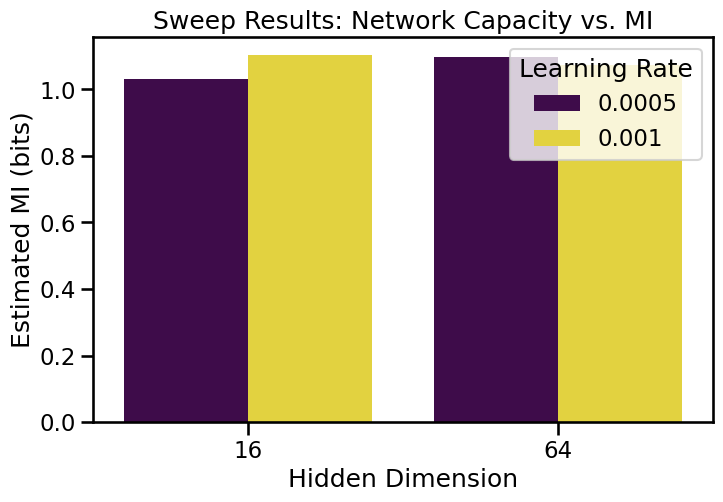

In [35]:
df = sweep_results.dataframe
display(df)

# Let's visualize the impact of hidden dimension
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='hidden_dim', y='mi_mean', hue='learning_rate', palette='viridis')
plt.title("Sweep Results: Network Capacity vs. MI")
plt.ylabel("Estimated MI (bits)")
plt.xlabel("Hidden Dimension")
plt.legend(title='Learning Rate')
plt.show()

## 3. Sweeping Physical Data Parameters

You can also sweep parameters related to the data processors, like `window_size`. 

When `nmi.run()` detects a data parameter in the `sweep_grid`, it is smart enough to defer the heavy lifting. Instead of pre-processing massive amounts of data in memory, it instructs each parallel worker to build its own specific chunks on the fly.

*(Note: We will run this sequentially for the tutorial, but on a large server, setting `n_workers=4` will process and train these different window sizes simultaneously!)*

In [36]:
window_sweep_grid = {
    'window_size': [0.05, 0.1, 0.2, 0.5]  # Try 50ms, 100ms, 200ms and 500ms windows
}

base_params = {
    'n_epochs': 25,     
    'patience': 5,    
    'learning_rate': 5e-4,
    'batch_size': 64,
    'embedding_dim': 8,
    'hidden_dim': 32,   # This will be swept over
    'n_layers': 1
}

window_results = nmi.run(
    x_data=x_raw, y_data=y_raw,
    mode='sweep',
    sweep_grid=window_sweep_grid,    # Sweeping the physical window size
    processor_type_x='continuous',
    processor_type_y='continuous',
    processor_params_x={},
    processor_params_y={},
    base_params=base_params,
    output_units='bits',
    random_seed=42
)

df_win = window_results.dataframe
display(df_win[['window_size', 'mi_mean', 'mi_std']])

2026-02-24 16:04:14 - neural_mi - INFO - Detected sweep over processor or lag parameters. Deferring data processing to workers.
2026-02-24 16:04:14 - neural_mi - INFO - Starting parameter sweep sequentially (n_workers=1)...


Sequential Sweep Progress:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-24 16:04:14 - neural_mi - INFO - Window coverage: 15672/199980 windows have sufficient data
2026-02-24 16:04:14 - neural_mi - INFO - Created 15672 aligned windows


Run 5bd95156-70e9-44c0-a96f-6277a4598973_c0:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:04:15 - neural_mi - INFO - Window coverage: 15672/199980 windows have sufficient data
2026-02-24 16:04:15 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:16 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:16 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:17 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:17 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:17 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:18 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:18 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data
2026-02-24 16:04:18 - neural_mi - INFO - Window coverage: 10000/199981 windows have sufficient data


...

Run 5bd95156-70e9-44c0-a96f-6277a4598973_c2:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:04:33 - neural_mi - INFO - Window coverage: 13222/49995 windows have sufficient data
2026-02-24 16:04:34 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:34 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:34 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:35 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:35 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:35 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:36 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:36 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24 16:04:36 - neural_mi - INFO - Window coverage: 10000/49996 windows have sufficient data
2026-02-24

Run 5bd95156-70e9-44c0-a96f-6277a4598973_c3:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:04:42 - neural_mi - INFO - Window coverage: 9999/19998 windows have sufficient data
2026-02-24 16:04:42 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:42 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:43 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:43 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:43 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:44 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:44 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:44 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 16:04:45 - neural_mi - INFO - Window coverage: 10000/19999 windows have sufficient data
2026-02-24 

,window_size,mi_mean,mi_std
0,0.05,0.986898,0.0
1,0.10,0.963240,0.0
2,0.20,1.018040,0.0
3,0.50,0.991640,0.0


## 4. Lag Analysis (`mode='lag'`)

Finding the temporal delay between brain regions or behaviors is one of the most common neuroscience tasks. 

`NeuralMI` includes a dedicated `mode='lag'`. It is a highly optimized sweep that tests a range of time shifts between $X$ and $Y$. 

**Why is it special?** Instead of re-slicing massive numpy arrays for every lag step, it utilizes the `SubsetView.time_shift()` architecture we discussed in Tutorial 2 to virtually shift the data in memory, making it incredibly fast.

In [37]:
# We will test lags from -0.3 seconds to +0.3 seconds in steps of 0.05s, that corresponds to -30 to +30 steps in our data
lags_to_test = np.arange(-30, 31, 5)

print("Starting Lag Analysis...")
lag_results = nmi.run(
    x_data=x_raw, y_data=y_raw,
    mode='lag',                      # Dedicated lag mode
    lag_range=lags_to_test,          # The range of delays to test
    processor_type_x='continuous',
    processor_type_y='continuous',
    processor_params_x={'window_size': 0.1},
    processor_params_y={'window_size': 0.1},
    base_params=base_params,
    output_units='bits',
    random_seed=42
)

Starting Lag Analysis...
2026-02-24 16:05:00 - neural_mi - INFO - Detected sweep over processor or lag parameters. Deferring data processing to workers.
2026-02-24 16:05:00 - neural_mi - INFO - Preparing 13 tasks for lag analysis.
2026-02-24 16:05:00 - neural_mi - INFO - Starting parameter sweep sequentially (n_workers=1)...


Sequential Sweep Progress:   0%|          | 0/13 [00:00<?, ?it/s]

2026-02-24 16:05:00 - neural_mi - INFO - Window coverage: 14908/99690 windows have sufficient data
2026-02-24 16:05:00 - neural_mi - INFO - Created 14908 aligned windows


Run lag-30_combo0:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:05:01 - neural_mi - INFO - Window coverage: 14908/99690 windows have sufficient data
2026-02-24 16:05:01 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:02 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:02 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:03 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:03 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:03 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:04 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:04 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:04 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:05:05

...

2026-02-24 16:06:27 - neural_mi - INFO - Window coverage: 14928/99790 windows have sufficient data
2026-02-24 16:06:28 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:28 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:29 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:29 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:29 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:30 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:30 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:30 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:31 - neural_mi - INFO - Window coverage: 9980/99791 windows have sufficient data
2026-02-24 16:06:31

Run lag25_combo0:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:06:32 - neural_mi - INFO - Window coverage: 14918/99740 windows have sufficient data
2026-02-24 16:06:33 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:33 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:34 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:34 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:34 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:35 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:35 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:35 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:36 - neural_mi - INFO - Window coverage: 9975/99741 windows have sufficient data
2026-02-24 16:06:36

Run lag30_combo0:   0%|          | 0/25 [00:00<?, ?it/s]

2026-02-24 16:06:41 - neural_mi - INFO - Window coverage: 14908/99690 windows have sufficient data
2026-02-24 16:06:42 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:42 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:43 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:43 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:43 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:44 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:44 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:44 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:45 - neural_mi - INFO - Window coverage: 9970/99691 windows have sufficient data
2026-02-24 16:06:45

### Visualizing the Tuning Curve

The output dataframe contains the MI for every tested lag. If we plot this, we expect to see a sharp peak exactly at the `0.15` second delay we injected into the raw data at the beginning of the tutorial.

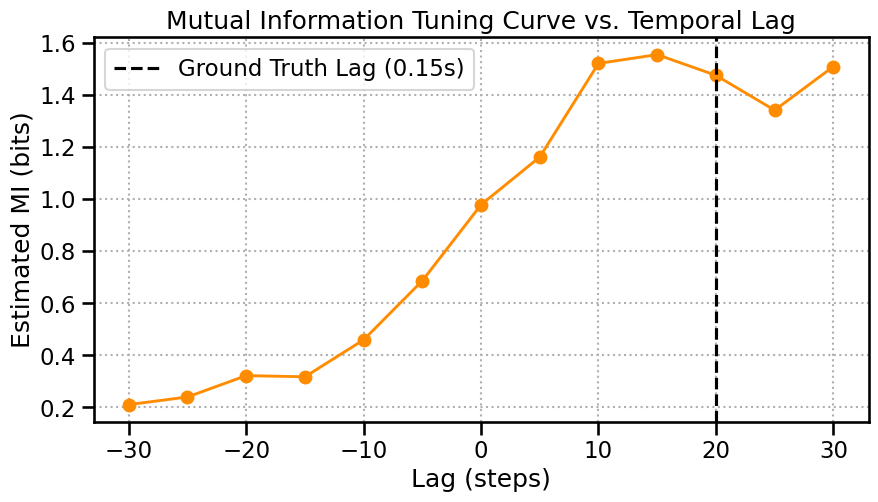

In [40]:
df_lag = lag_results.dataframe

plt.figure(figsize=(10, 5))
plt.plot(df_lag['lag'], df_lag['mi_mean'], marker='o', linewidth=2, color='darkorange')
plt.fill_between(df_lag['lag'], 
                 df_lag['mi_mean'] - df_lag['mi_std'], 
                 df_lag['mi_mean'] + df_lag['mi_std'], 
                 color='darkorange', alpha=0.2)

# Draw a line at the known ground truth
plt.axvline(x=true_lag_steps, color='black', linestyle='--', label='Ground Truth Lag (0.15s)')

plt.title("Mutual Information Tuning Curve vs. Temporal Lag")
plt.xlabel("Lag (steps)")
plt.ylabel("Estimated MI (bits)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## 5. Conclusion

You have successfully scaled your analysis!

- You used `mode='sweep'` to explore a grid of hyperparameter combinations automatically.
- You learned that `nmi.run()` intelligently handles sweeps over physical window sizes.
- You used `mode='lag'` to uncover the underlying temporal dynamics of the data, accurately recovering the 0.15-second delay we hid in the signal.

In the next tutorial, we will look at `mode='rigorous'`, which applies powerful bias-correction algorithms to ensure the MI value you estimate is a mathematically sound lower bound ready for publication.